#RSLS First Neural Network Iteration


LSTM models are good for storing information that's important and forgetting data that's not important

Description: This program will be predicting the closing stock prices using a recurrent neural network known as Long Short Term Memory (LSTM)

We will use past 60 day stock price to maintain relavancy

In [ ]:
#Import the libraries

import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yf
plt.style.use('seaborn-v0_8-darkgrid')

/usr/local/lib/python3.10/dist-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [ ]:
#get the stock quote that we want
yf.pdr_override()
df = pdr.get_data_yahoo('AAPL', start ='2013-01-01', end='2023-05-17')

#call df to show apple's data
df

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-01-02,19.779285,19.821428,19.343929,19.608213,16.747719,560518000
2013-01-03,19.567142,19.631071,19.321428,19.360714,16.536337,352965200
2013-01-04,19.177500,19.236786,18.779642,18.821428,16.075720,594333600
2013-01-07,18.642857,18.903570,18.400000,18.710714,15.981152,484156400
2013-01-08,18.900356,18.996071,18.616072,18.761070,16.024160,458707200
...,...,...,...,...,...,...
2023-05-10,173.020004,174.029999,171.899994,173.559998,172.638504,53724500
2023-05-11,173.850006,174.589996,172.169998,173.750000,172.827499,49514700
2023-05-12,173.619995,174.059998,171.000000,172.570007,171.891190,45497800


In [ ]:
#get number of rows and columns to see how much data we have

df.shape
#this gives us (2661,6) which represents that we have 2661 rows of data and 6 columns

(2611, 6)

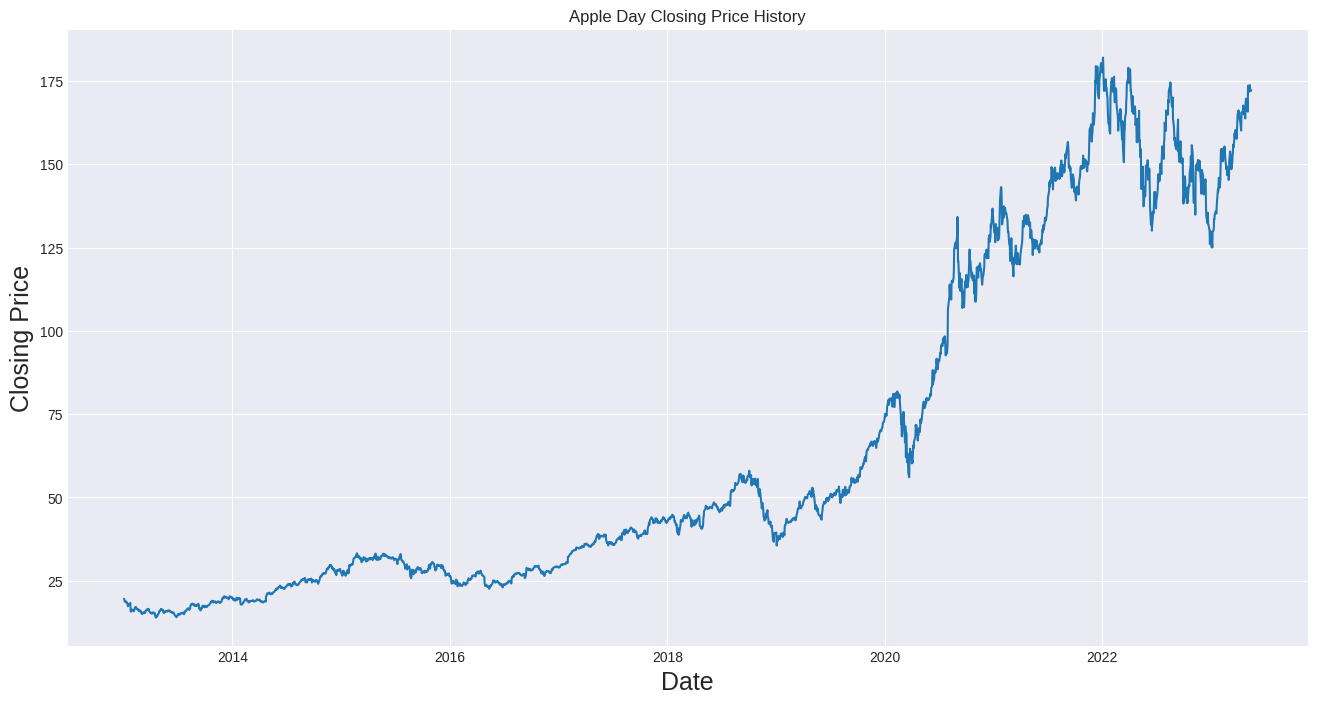

In [ ]:
#visualize closing price

plt.figure(figsize=(16,8))  #creates a plot figure for us to use and specifies the size
plt.title("Apple Day Closing Price History") #creates the title
plt.plot(df['Close'])  #specifies in the df what column we want to plot
plt.xlabel("Date", fontsize = 18) #labels x axis
plt.ylabel("Closing Price", fontsize = 18)  #labels y axis
plt.show()  #everything above creates the plot but .show is the code that actually displays the plot for us to see

In [ ]:
#Now we need to create a dataframe that has the target data that we want to find
#In this case we want to have a new dataframe with the "Close" column only

closeData = df.filter(['Close'])  #df is our previous dataframe and .filter specifies that we only want 'Close'

#with neural networks its best if we have our data converted into a numpy array so we can manipulate it

dataset = closeData.values #.values is a numpy function that converts it into an array

#as with all machine learning models, we only want to specify the length of our training dataset and testing dataset
#we do this because we don't want our testing dataset to be all of our data, we want to make sure that it works on new data as well

training_data_length = math.ceil( len(dataset) * 0.7) #math.ceil just rounds it up to a whole number

training_data_length #gives us 1828 rows of data that we're working with for training data

1828

In [ ]:
#now we need to split our dataset into a training dataset and a testing dataset. We'll start with our training data first

#lists work by doing [start, end] so what this is saying is splice from 0 to the training_data_length and : returns all the columns in those rows
#by all columns note that we only have one column in 'dataset' which are the closeData.values
train_datasetBfs = dataset[0:training_data_length, :]

#Bfs means Before Scaler to signal that we've separated the two to prevent data leakage but we still need to scale them
train_datasetBfs

array([[19.60821342],
       [19.36071396],
       [18.8214283 ],
       ...,
       [61.23249817],
       [60.35250092],
       [65.61750031]])

In [ ]:
#create testing dataset
#this gets the data from where we last left off and -1 just means the first value of the list going backward i.e the last value in the list
#Printing it out the last result is 172.07 which is today's 5/16/2023 APPL stock price
#we have -60 there since we need data from past 60 days and this allows us to grab that to predict the value that's right after those 60 days
test_datasetBfs = dataset[training_data_length-60:, :]
test_datasetBfs

array([[ 77.58249664],
       [ 79.23999786],
       [ 78.16999817],
       [ 77.83499908],
       [ 78.80999756],
       [ 79.68250275],
       [ 79.14250183],
       [ 79.42500305],
       [ 79.80750275],
       [ 79.57749939],
       [ 77.23750305],
       [ 79.42250061],
       [ 81.08499908],
       [ 80.96749878],
       [ 77.37750244],
       [ 77.16500092],
       [ 79.71250153],
       [ 80.36250305],
       [ 81.30249786],
       [ 80.00749969],
       [ 80.38749695],
       [ 79.90249634],
       [ 81.80000305],
       [ 81.21749878],
       [ 81.23750305],
       [ 79.75      ],
       [ 80.90499878],
       [ 80.07499695],
       [ 78.26249695],
       [ 74.54499817],
       [ 72.01999664],
       [ 73.16249847],
       [ 68.37999725],
       [ 68.33999634],
       [ 74.70249939],
       [ 72.33000183],
       [ 75.68499756],
       [ 73.23000336],
       [ 72.25749969],
       [ 66.54250336],
       [ 71.33499908],
       [ 68.85749817],
       [ 62.05749893],
       [ 69

In [ ]:
#now we need to scale our data into crunchable points from 0-1 so the data is consistent
scaler = MinMaxScaler(feature_range = (0,1)) #simply the code needed to make a scaler function from 0-1


#!!! IMPORTANT to note that we only scale after we've separated our training and testing dataset to prevent data leakage
train_dataset = scaler.fit_transform(train_datasetBfs)
test_dataset = scaler.fit_transform(test_datasetBfs)

#printing out these datasets we see that the values are now between 0 and 1
train_dataset
test_dataset

array([[0.17066729],
       [0.18383068],
       [0.17533306],
       [0.17267259],
       [0.18041574],
       [0.18734493],
       [0.1830564 ],
       [0.18529994],
       [0.18833764],
       [0.18651102],
       [0.16792745],
       [0.18528007],
       [0.19848314],
       [0.19754999],
       [0.16903929],
       [0.16735166],
       [0.18758317],
       [0.19274529],
       [0.20021045],
       [0.18992596],
       [0.19294378],
       [0.18909205],
       [0.2041615 ],
       [0.19953542],
       [0.19969428],
       [0.18788097],
       [0.19705363],
       [0.190462  ],
       [0.17606765],
       [0.14654436],
       [0.12649154],
       [0.13556496],
       [0.09758373],
       [0.09726605],
       [0.14779519],
       [0.12895351],
       [0.15559791],
       [0.13610106],
       [0.12837772],
       [0.08299089],
       [0.12105149],
       [0.1013759 ],
       [0.04737229],
       [0.1064189 ],
       [0.03542004],
       [0.05656483],
       [0.04427503],
       [0.040

In [ ]:
#now that we have our datasets created and scaled we need to choose what our x and y values will be
#x are the values that we're using for input and y are the values that we are trying to find
#in the case of LSTM, our input values would be the past 60 days while the output we're trying to find is tomorrow's stock price

x_train = [] #values of past 60 days (input)
y_train = [] #value of stock we're trying to predict (output)

#this simply means to start from 60 and go all the way to the end of the length of our dataset 1828
for i in range (60, len(train_dataset)):
  #the reason why we started at range 60 is because we subtract the 60 values and then splice from 0 to the 60th value (noninclusive)
  #with the for loop it helps us iterate throughout all of the training dataset since 60-60=0 and then 61-60=1 and so forth
  x_train.append(train_dataset[i-60:i, 0])
  y_train.append(train_dataset[i,0]) #i this time is inclusive so the x_train gets 60 values before predicted date and this value is the date we're guessing
  if i <= 60:
    print(x_train)
    print(y_train)

    #when printing it out you see that we get an array of 60 previous values (x_train) and 1 value at the bottom which is our predicted value (y_train)


[array([0.08342674, 0.07977913, 0.07183122, 0.07019953, 0.07094167,
       0.06662034, 0.06999427, 0.06830468, 0.05854085, 0.0502087 ,
       0.0608252 , 0.05903033, 0.05761973, 0.06013043, 0.06499392,
       0.03156533, 0.02597546, 0.03121266, 0.03565506, 0.03489712,
       0.03419181, 0.03320753, 0.02725976, 0.03542874, 0.03517083,
       0.04089227, 0.04445041, 0.04705583, 0.04072383, 0.04025538,
       0.04003432, 0.03664988, 0.03656037, 0.03069684, 0.0292283 ,
       0.03172848, 0.02751241, 0.03076   , 0.02844404, 0.02677552,
       0.02102249, 0.01553791, 0.02137514, 0.01849073, 0.02108039,
       0.02168043, 0.02491749, 0.01994873, 0.01990662, 0.02209099,
       0.02796507, 0.03431288, 0.03366547, 0.03239694, 0.03273907,
       0.03757099, 0.03845   , 0.0371657 , 0.03239694, 0.02743872])]
[0.02020137991372581]


In [ ]:
#convert training data into numpy array as its in a dictionary array format right now
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
#LSTM works with 3 dimensional shapes but currently our arrays are 2 dimensional

x_train.shape #this gives us (1768, 60) so only 2 dimensions with 1768 rows and 60 columns

#reshape
#x_train.shape[0] just gives us the 1768 while x_train.shape[1] gives us 60
#Syntax: np.reshape(whatToShape, dimensionalValues)
x_train = np.reshape(x_train, (x_train.shape[0] , x_train.shape[1], 1))

#gets new shape which is (1768, 60, 1)
x_train.shape

(1768, 60, 1)

In [ ]:
#Now that we have our training data we can build our LSTM model

model = Sequential() #meaning that it goes from right to left
model.add(LSTM(50, return_sequences = True, input_shape = (x_train.shape[1], 1))) #gives us a layer of 50 LSTM neurons and return_sequences = True since we'll have on more LSTM layer
model.add(LSTM(50, return_sequences = False))  #return_sequences = False since no more LSTM
model.add(Dense(25)) #your normal densely connected neuron
model.add(Dense(1))



In [ ]:
#compile the model
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
#train the model
model.fit(x_train,y_train, batch_size = 32, epochs = 10, verbose = 1)

Epoch 1/10
56/56 [==============================] - 5s 31ms/step - loss: 0.0083
Epoch 2/10
56/56 [==============================] - 2s 31ms/step - loss: 5.6508e-04
Epoch 3/10
56/56 [==============================] - 2s 31ms/step - loss: 4.7491e-04
Epoch 4/10
56/56 [==============================] - 2s 31ms/step - loss: 4.4558e-04
Epoch 5/10
56/56 [==============================] - 2s 31ms/step - loss: 4.1849e-04
Epoch 6/10
56/56 [==============================] - 2s 38ms/step - loss: 4.4861e-04
Epoch 7/10
56/56 [==============================] - 2s 31ms/step - loss: 4.1149e-04
Epoch 8/10
56/56 [==============================] - 2s 31ms/step - loss: 3.8679e-04
Epoch 9/10
56/56 [==============================] - 2s 31ms/step - loss: 3.8389e-04
Epoch 10/10
56/56 [==============================] - 2s 31ms/step - loss: 3.7502e-04


In [ ]:
#now that we've trained our training model we can run it against our testing data

#remember that our test_dataset has already been scaled
x_test = []
y_test = dataset[training_data_length:,:]
yChecker = []

for i in range(60, len(test_dataset)):
  x_test.append(test_dataset[i-60:i, 0])
  yChecker.append(test_datasetBfs[i,0])
y_test


array([[ 64.85749817],
       [ 66.51750183],
       [ 66.99749756],
       [ 68.3125    ],
       [ 71.76249695],
       [ 71.10749817],
       [ 71.67250061],
       [ 70.69999695],
       [ 69.23249817],
       [ 67.09249878],
       [ 69.02500153],
       [ 68.75749969],
       [ 70.74250031],
       [ 70.79250336],
       [ 69.64499664],
       [ 71.93250275],
       [ 73.44999695],
       [ 72.26750183],
       [ 73.29000092],
       [ 74.38999939],
       [ 75.15750122],
       [ 75.93499756],
       [ 77.53250122],
       [ 78.75250244],
       [ 77.85250092],
       [ 76.91249847],
       [ 77.38500214],
       [ 76.92749786],
       [ 78.73999786],
       [ 78.28500366],
       [ 79.80750275],
       [ 79.21250153],
       [ 79.72250366],
       [ 79.18250275],
       [ 79.52749634],
       [ 79.5625    ],
       [ 79.48500061],
       [ 80.46250153],
       [ 80.83499908],
       [ 81.27999878],
       [ 80.58000183],
       [ 82.875     ],
       [ 83.36499786],
       [ 85

In [ ]:
#CAVIAT! Initially I wanted to do the yChecker way as it was my preferred method
#It turns out that the reason why yChecker didn't work at first and gave us a 132 rmse was because it had a shape of 0 instead of 1




newY = np.reshape(yChecker, (len(yChecker), 1))
newY.shape

(783, 1)

In [ ]:
#convert to numpy array to be used in LSTM model

#x_test, y_test = np.array(x_test), np.array(y_test)

#newY = np.array(newY)
#newY

x_test = np.array(x_test)

In [ ]:
#Reshape data again but for test dataset
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1)) #rows, columns, features that we're looking at which is just closed price
x_test.shape

(783, 60, 1)

In [ ]:
#get predictions
predictions = model.predict(x_test) #calls the LSTM neural network known as "model" to predict our testing values

predictions = scaler.inverse_transform(predictions) #scaler.inverse_transform turns our 0-1 values into their original value to plot

predictions

25/25 [==============================] - 1s 10ms/step


array([[ 61.581814],
       [ 61.985214],
       [ 62.55504 ],
       [ 63.233765],
       [ 64.028786],
       [ 65.07924 ],
       [ 66.19448 ],
       [ 67.31761 ],
       [ 68.306046],
       [ 69.03692 ],
       [ 69.39829 ],
       [ 69.61247 ],
       [ 69.69453 ],
       [ 69.81553 ],
       [ 69.959435],
       [ 70.033035],
       [ 70.20776 ],
       [ 70.54199 ],
       [ 70.88313 ],
       [ 71.275085],
       [ 71.74924 ],
       [ 72.29951 ],
       [ 72.91758 ],
       [ 73.64948 ],
       [ 74.493515],
       [ 75.29506 ],
       [ 75.94818 ],
       [ 76.48776 ],
       [ 76.88051 ],
       [ 77.27225 ],
       [ 77.604095],
       [ 77.979256],
       [ 78.31606 ],
       [ 78.63987 ],
       [ 78.89421 ],
       [ 79.107956],
       [ 79.28104 ],
       [ 79.40879 ],
       [ 79.56513 ],
       [ 79.75541 ],
       [ 79.98678 ],
       [ 80.18062 ],
       [ 80.49743 ],
       [ 80.908806],
       [ 81.54296 ],
       [ 82.441505],
       [ 83.15617 ],
       [ 83.7

In [ ]:
#get root mean squared error or loss in this case
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse #this gives us 6.23 which is not bad but we want to get as close to 0 as possible

4.694855594629615

<ipython-input-21-390daa6083f6>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions #adds a predictions column onto our valid df


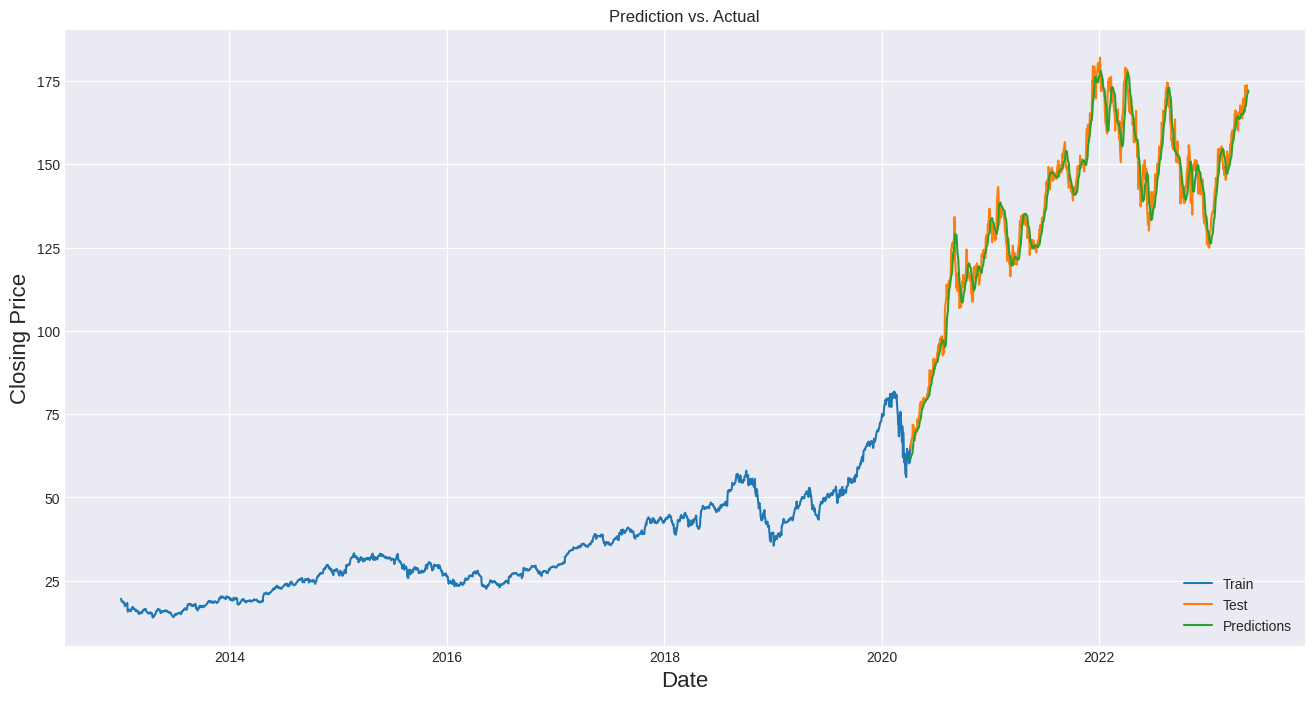

In [ ]:
#the close data set is just the dataframe with the close column info which is what we're grabbing
#"dataset" variable is a numpy array that we use for calculation based on the close dataset
#however since we are plotting out values we don't want a numpy array but rather a pd dataframe to manipulate
train = closeData[:training_data_length]  #grabs all the data up to the training date
valid = closeData[training_data_length:]  #grabs all the data up from test start to end

valid['Predictions'] = predictions #adds a predictions column onto our valid df

#creating the visualization
plt.figure(figsize = (16,8))
plt.title('Prediction vs. Actual')
plt.xlabel('Date',fontsize = 16)
plt.ylabel('Closing Price', fontsize = 16)

#plotting it out
plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Train','Test','Predictions'], loc='lower right')
plt.show()

In [ ]:
#call valid to compare our predictions vs. the actual closing price
valid

,Close,Predictions
Date,,
2020-04-07,64.857498,61.581814
2020-04-08,66.517502,61.985214
2020-04-09,66.997498,62.555038
2020-04-13,68.312500,63.233765
2020-04-14,71.762497,64.028786
...,...,...
2023-05-10,173.559998,169.192261
2023-05-11,173.750000,170.040695
2023-05-12,172.570007,170.872726


In [ ]:


acc = valid['Close'].sum()/valid['Predictions'].sum()
acc

1.0058821950979724